# RF coupling strength: populated → m1=+1/2 sibling transition (magnetic RF)

Companion to `demo_ramsey_rf_splittings.ipynb`. Same target transition (the ~120 kHz splitting between the populated state and its m1=+1/2 sibling), but here we plot the **coupling strength** of the transition driven by the demo's RF field.

**The RF field is magnetic** (B-field along x̂, perpendicular to the DC E-field along ẑ). The relevant operator is the Zeeman x-coupling `HZx`, NOT the Stark coupling `HSx`. This is an NMR-style nuclear-spin-flip transition driven directly by the nuclear Zeeman interaction.

Two views of "coupling strength":

- **Bare matrix element** `|⟨sib | HZx | pop⟩|` in Hz/G — independent of the RF amplitude. The Hungarian-tracked dressed-state matrix element of the magnetic-dipole operator.
- **Rabi frequency** `Ω/(2π) = (1/2) · B_rf · |⟨sib|HZx|pop⟩|` in Hz, within RWA on resonance. Multiplied either by the actual RF spatial envelope `B_rf(z)` (vs-z view → shows where the molecule sees coupling) or by the peak amplitude `B_RF_AMPLITUDE` (vs-|E_dc| view → field-dependence of the peak Rabi).

**Why this works (unlike the electric case).** `HZx` includes the nuclear Zeeman term `μ_Tl·I_Tl + μ_F·I_F` projected onto x̂. The `I_Tl,x = (I+ + I-)/2` operator directly flips m1 (the Tl spin projection) by ±1, so the bare matrix element `⟨sib_bare | HZx | pop_bare⟩` is non-zero **at zeroth order** — direct numerical check shows ≈ −1240 Hz/G. No 2nd-order suppression, no Stark mediation needed. The matrix element should therefore be only weakly dependent on the DC field (the Stark just mixes J at fixed mJ, m1, m2 — the nuclear Zeeman amplitude is largely preserved).

Contrast with the (incorrect) electric picture: `HSx` is strictly diagonal in (m1, m2) (the molecular dipole acts only on rotational coordinates), so the populated→sibling transition is forbidden at 1st order and only appears via small spin-rotation admixtures (~Hz/(V/cm) at 30 kV/cm). The actual physics — magnetic RF — gives a much larger coupling.

In [1]:
from __future__ import annotations

import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linear_sum_assignment

HERE = os.path.dirname(os.path.abspath("demo_ramsey_rf_coupling.ipynb"))
if HERE not in sys.path:
    sys.path.insert(0, HERE)

from centrex_tlf.hamiltonian import generate_uncoupled_hamiltonian_X
from centrex_tlf.states import ElectronicState, UncoupledBasisState

from ramsey_rf import (
    AnalyticDCField,
    adiabatic_dressed_initial_states,
    build_H_func,
    build_basis,
    dressed_initial_states,
)
from ramsey_rf.states import UncoupledSelector

%matplotlib inline

## 1. Geometry and RF parameters (matches `demo_ramsey_rf.ipynb`)

In [ ]:
DC_HALF_WIDTH = 1.50  # m
DC_RAMP_LENGTH = 0.05  # m
E_LOW, E_HIGH = 2e3, 30e3  # V/cm  (DC E-field, electric)
Z_START, Z_FINAL = -2.0, +2.0  # m

# RF coil geometry (from demo_ramsey_rf.ipynb)
Z_RF1, Z_RF2 = -1.25, +1.25  # m, RF coil centers
RF_WIDTH = 0.30  # m
RF_EDGE = 0.05  # m
OMEGA_RF = 2 * np.pi * 120e3  # rad/s

# RF magnetic-field amplitude (placeholder — the demo's RF_AMPLITUDE = 20 V/cm is
# mislabeled, the field is actually magnetic; see notebook header).
# With matrix element ≈ 1.37 kHz/G (computed below), the pulse area in one coil is
#   pulse_area ≈ 2π · (B_rf · |M|/2) · (RF_WIDTH / v_z) = B_rf [G] · 6.95
# So B_rf ≈ 0.226 G gives a clean π/2 in one coil. 0.04 G gives ~0.09π — far below
# π/2; chose this small value as a conservative placeholder so that the trajectory
# plot shows clear sub-π pulses rather than many Rabi cycles. Replace with the
# actual measured B_rf for quantitative analysis.
B_RF_AMPLITUDE = 0.04  # Gauss

# Static-eigh sweep: Jmax=6 captures full J-mixing at 30 kV/cm.
JMAX = 6

# Tiny B bias along z to lift exact zero-field degeneracies (Hungarian needs unique eigenvectors).
B_BIAS = np.array([0.0, 0.0, 1e-5])

dc = AnalyticDCField.symmetric_plateau(
    E_low=E_LOW,
    E_high=E_HIGH,
    half_width=DC_HALF_WIDTH,
    ramp_length=DC_RAMP_LENGTH,
    direction=(0, 0, 1),
)


def rf_envelope_z(z: float) -> float:
    """Sum of two rounded-rectangle RF coil envelopes at z=Z_RF1 and z=Z_RF2.

    Peak value = B_RF_AMPLITUDE Gauss inside each coil. Same spatial profile
    (tanh-rounded rectangle, width=RF_WIDTH, edge_length=RF_EDGE) as the demo's
    AnalyticRFRegion, but normalized in B-field units instead of E-field units.
    """
    half = 0.5 * RF_WIDTH

    def _one(z_center: float) -> float:
        left = np.tanh((z - (z_center - half)) / RF_EDGE)
        right = np.tanh((z - (z_center + half)) / RF_EDGE)
        return B_RF_AMPLITUDE * 0.5 * (left - right)

    return _one(Z_RF1) + _one(Z_RF2)

## 2. Basis, H_func, and the bare HZx Zeeman-coupling matrix

`generate_uncoupled_hamiltonian_X(QN)` returns a `HamiltonianUncoupledX` dataclass exposing `Hff`, `HSx`, `HSy`, `HSz` (Stark sub-matrices, units Hz/(V/cm)) and `HZx`, `HZy`, `HZz` (Zeeman sub-matrices, units Hz/G). The bundled `H_func(E, B)` (used in the splittings notebook) computes `2π·(Hff + E·HS + B·HZ)` in rad/s. Here we keep the bundled callable for the eigh sweep, AND extract `HZx` directly so we can compute matrix elements `⟨b | HZx | a⟩` in `Hz/G` for the magnetic RF coupling.

In [3]:
QN = build_basis(Jmax=JMAX)
H_func = build_H_func(QN)
H_uncoupled = generate_uncoupled_hamiltonian_X(QN)
HZx = H_uncoupled.HZx  # complex Hermitian, Hz/G; ⟨b|HZx|a⟩ × B_x = Hz coupling
print(f"Basis size: {len(QN)} (Jmax={JMAX})")
print(f"HZx shape: {HZx.shape}, dtype: {HZx.dtype}, max |element|: {np.abs(HZx).max():.3e} Hz/G")

Basis size: 196 (Jmax=6)
HZx shape: (196, 196), dtype: complex128, max |element|: 2.004e+03 Hz/G


## 3. Identify populated and m1=+1/2 sibling at 2 kV/cm

Same procedure as the splittings notebook: bare-state targets at 30 kV/cm, walked back to 2 kV/cm via `adiabatic_dressed_initial_states` to get the dressed-eigenstate column index at the start of the |E| sweep.

In [4]:
E_low_vec = np.array([0.0, 0.0, E_LOW])
E_high_vec = np.array([0.0, 0.0, E_HIGH])

target_pop = UncoupledBasisState(
    J=1, mJ=-1, I1=0.5, m1=-0.5, I2=0.5, m2=-0.5,
    Omega=0, P=-1, electronic_state=ElectronicState.X,
)
target_sib = UncoupledBasisState(
    J=1, mJ=-1, I1=0.5, m1=+0.5, I2=0.5, m2=-0.5,
    Omega=0, P=-1, electronic_state=ElectronicState.X,
)

_, pop_init_idx, pop_overlap_high = adiabatic_dressed_initial_states(
    H_func, E_init=E_low_vec, E_target=E_high_vec, QN=QN,
    targets=[target_pop], n_steps=80, B=B_BIAS,
)
_, sib_init_idx, sib_overlap_high = adiabatic_dressed_initial_states(
    H_func, E_init=E_low_vec, E_target=E_high_vec, QN=QN,
    targets=[target_sib], n_steps=80, B=B_BIAS,
)
populated_idx = int(pop_init_idx[0])
sibling_idx = int(sib_init_idx[0])
print(f"populated_idx = {populated_idx}  |⟨target_pop | dressed at 30 kV/cm⟩|² = {pop_overlap_high[0]:.4f}")
print(f"sibling_idx   = {sibling_idx}  |⟨target_sib | dressed at 30 kV/cm⟩|² = {sib_overlap_high[0]:.4f}")

populated_idx = 11  |⟨target_pop | dressed at 30 kV/cm⟩|² = 0.5962
sibling_idx   = 7  |⟨target_sib | dressed at 30 kV/cm⟩|² = 0.5941


## 4. Sweep |E| with Hungarian tracking; compute matrix element on the fly

Same uniform-|E| sweep as the splittings notebook (2001 points, ΔE = 14 V/cm). At each step, after Hungarian reordering, extract the populated and sibling Hungarian-tracked eigenvectors and compute `M(|E|) = ⟨sib | HZx | pop⟩` (complex, Hz/G). Only the scalar matrix element is stored — full V matrices would be ~1.2 GB, the scalar is 32 KB.

In [5]:
N_E = 2001
E_grid = np.linspace(E_LOW, E_HIGH, N_E)
N_basis = len(QN)

energies_E = np.empty((N_E, N_basis), dtype=np.float64)
M_xE = np.empty(N_E, dtype=np.complex128)  # ⟨sib|HZx|pop⟩ at each |E|, in Hz/G
V_low_tracked = None

t0 = time.perf_counter()
prev_vectors = None
for i, Emag in enumerate(E_grid):
    H = H_func(np.array([0.0, 0.0, Emag]), B_BIAS)
    eigenvalues, eigenvectors = np.linalg.eigh(H)
    if prev_vectors is None:
        energies_E[i] = eigenvalues
        prev_vectors = eigenvectors
        V_low_tracked = eigenvectors.copy()
    else:
        cost = -np.abs(prev_vectors.conj().T @ eigenvectors)
        _, col_ind = linear_sum_assignment(cost)
        energies_E[i] = eigenvalues[col_ind]
        prev_vectors = eigenvectors[:, col_ind]
    v_pop = prev_vectors[:, populated_idx]
    v_sib = prev_vectors[:, sibling_idx]
    M_xE[i] = v_sib.conj() @ HZx @ v_pop
V_high_tracked = prev_vectors
elapsed = time.perf_counter() - t0

abs_M_xE = np.abs(M_xE)  # Hz/G
print(f"|E| sweep: {N_E} points, basis {N_basis}, wall time {elapsed:.1f} s")
print(
    f"|⟨sib|HZx|pop⟩|: "
    f"{abs_M_xE[0]:.4e} Hz/G at 2 kV/cm  →  "
    f"{abs_M_xE[-1]:.4e} Hz/G at 30 kV/cm"
)
print(
    f"Peak Rabi Ω/(2π) at B_RF_AMPLITUDE={B_RF_AMPLITUDE} G: "
    f"{0.5 * B_RF_AMPLITUDE * abs_M_xE[0]:.3f} Hz at 2 kV/cm  →  "
    f"{0.5 * B_RF_AMPLITUDE * abs_M_xE[-1]:.3f} Hz at 30 kV/cm"
)

|E| sweep: 2001 points, basis 196, wall time 172.3 s
|⟨sib|HZx|pop⟩|: 1.3667e+03 Hz/G at 2 kV/cm  →  1.3584e+03 Hz/G at 30 kV/cm
Peak Rabi Ω/(2π) at B_RF_AMPLITUDE=0.04 G: 27.335 Hz at 2 kV/cm  →  27.169 Hz at 30 kV/cm


## 5. State confirmation — bare composition of populated and sibling

Sanity check: print the dominant bare components of populated and sibling at 2 kV/cm and 30 kV/cm. Identical structure to Section 6 of the splittings notebook. mJ, m1, m2 are conserved by the static Stark Hamiltonian (E ∥ ẑ; nuclear-Stark coupling negligible), so only J is mixed.

In [6]:
def _print_top_components(v, n_top=4, indent="    "):
    amps = np.abs(v) ** 2
    for idx in np.argsort(amps)[::-1][:n_top]:
        bs = QN[idx]
        print(
            f"{indent}|J={bs.J}, mJ={bs.mJ:+d}, m1={bs.m1:+.1f}, m2={bs.m2:+.1f}>: "
            f"|amp|^2={amps[idx]:.4f}"
        )


print(f"=== POPULATED state (col {populated_idx}): bare composition ===")
print("  At  2 kV/cm:")
_print_top_components(V_low_tracked[:, populated_idx])
print("  At 30 kV/cm (Hungarian-tracked):")
_print_top_components(V_high_tracked[:, populated_idx])

print(f"\n=== SIBLING state (col {sibling_idx}): bare composition ===")
print("  At  2 kV/cm:")
_print_top_components(V_low_tracked[:, sibling_idx])
print("  At 30 kV/cm (Hungarian-tracked):")
_print_top_components(V_high_tracked[:, sibling_idx])

=== POPULATED state (col 11): bare composition ===
  At  2 kV/cm:
    |J=1, mJ=-1, m1=-0.5, m2=-0.5>: |amp|^2=0.9950
    |J=2, mJ=-1, m1=-0.5, m2=-0.5>: |amp|^2=0.0050
    |J=3, mJ=-1, m1=-0.5, m2=-0.5>: |amp|^2=0.0000
    |J=1, mJ=+1, m1=+0.5, m2=+0.5>: |amp|^2=0.0000
  At 30 kV/cm (Hungarian-tracked):
    |J=1, mJ=-1, m1=-0.5, m2=-0.5>: |amp|^2=0.5962
    |J=2, mJ=-1, m1=-0.5, m2=-0.5>: |amp|^2=0.3518
    |J=3, mJ=-1, m1=-0.5, m2=-0.5>: |amp|^2=0.0493
    |J=4, mJ=-1, m1=-0.5, m2=-0.5>: |amp|^2=0.0025

=== SIBLING state (col 7): bare composition ===
  At  2 kV/cm:
    |J=1, mJ=-1, m1=+0.5, m2=-0.5>: |amp|^2=0.9908
    |J=2, mJ=-1, m1=+0.5, m2=-0.5>: |amp|^2=0.0050
    |J=1, mJ=-1, m1=-0.5, m2=+0.5>: |amp|^2=0.0041
    |J=2, mJ=-1, m1=-0.5, m2=+0.5>: |amp|^2=0.0000
  At 30 kV/cm (Hungarian-tracked):
    |J=1, mJ=-1, m1=+0.5, m2=-0.5>: |amp|^2=0.5941
    |J=2, mJ=-1, m1=+0.5, m2=-0.5>: |amp|^2=0.3506
    |J=3, mJ=-1, m1=+0.5, m2=-0.5>: |amp|^2=0.0492
    |J=4, mJ=-1, m1=+0.5, m2=-0.5>:

## 6. Map matrix element onto the trajectory; evaluate RF envelope on z

`E_dc(z)` is monotonic on each leg of the trajectory, so we can interpolate `|M(|E|)|` at `|E_dc(z)|` per `np.interp`. The RF magnetic-field envelope `rf_envelope_z(z)` is the rounded-rectangle profile defined in Section 1, peaking at `B_RF_AMPLITUDE` Gauss inside each coil at z = ±1.25 m, zero outside.

In [7]:
z_grid = np.linspace(Z_START, Z_FINAL, 1001)
E_dc_mag_z = np.array([float(np.linalg.norm(dc(np.array([0.0, 0.0, z])))) for z in z_grid])
abs_M_z = np.interp(E_dc_mag_z, E_grid, abs_M_xE)  # Hz/G at each z
B_rf_z = np.array([rf_envelope_z(z) for z in z_grid])  # Gauss at each z

# Rabi frequency Ω/(2π) in Hz, within RWA, on resonance.
rabi_z_Hz = 0.5 * B_rf_z * abs_M_z                  # vs z: actual experienced Rabi
rabi_E_Hz = 0.5 * B_RF_AMPLITUDE * abs_M_xE         # vs |E|: peak Rabi (assume inside coil)

print(
    f"Peak |B_rf(z)| = {B_rf_z.max():.4f} G  "
    f"(should be ≈ B_RF_AMPLITUDE = {B_RF_AMPLITUDE} G at z=±1.25 m)"
)
print(
    f"Peak Rabi(z)/(2π) along trajectory = {rabi_z_Hz.max():.2f} Hz  "
    f"(at z = {z_grid[np.argmax(rabi_z_Hz)]:+.3f} m, |E_dc| = {E_dc_mag_z[np.argmax(rabi_z_Hz)] * 1e-3:.2f} kV/cm)"
)
# Pulse-area sanity check
v_z = 184.0  # m/s, from demo
t_in_coil = RF_WIDTH / v_z
pulse_area_rad = 2 * np.pi * rabi_z_Hz.max() * t_in_coil
print(
    f"Pulse area in one coil (Ω · t_coil) ≈ {pulse_area_rad:.3f} rad "
    f"({pulse_area_rad / np.pi:.3f} π) — π/2 ≈ 1.571 rad"
)

Peak |B_rf(z)| = 0.0398 G  (should be ≈ B_RF_AMPLITUDE = 0.04 G at z=±1.25 m)
Peak Rabi(z)/(2π) along trajectory = 27.03 Hz  (at z = -1.252 m, |E_dc| = 30.00 kV/cm)
Pulse area in one coil (Ω · t_coil) ≈ 0.277 rad (0.088 π) — π/2 ≈ 1.571 rad


## 7. Plot A: vs z (round-trip view)

- **Top:** Rabi frequency `Ω(z)/(2π) = (1/2) · B_rf(z) · |M(|E_dc(z)|)|` in Hz — what the molecule actually experiences as it traverses the apparatus. Two narrow peaks at z = ±1.25 m (the RF coils) on top of the 30 kV/cm DC plateau, modulated by the matrix element evaluated at the local DC field.
- **Bottom:** Bare matrix element `|⟨sib|HZx|pop⟩|(|E_dc(z)|)` in Hz/G — independent of the RF coils, depends only on the local DC field. For a direct nuclear-Zeeman transition the matrix element is dominated by the bare nuclear-spin gyromagnetic ratio (~kHz/G scale) and only weakly affected by the Stark-induced J-mixing.

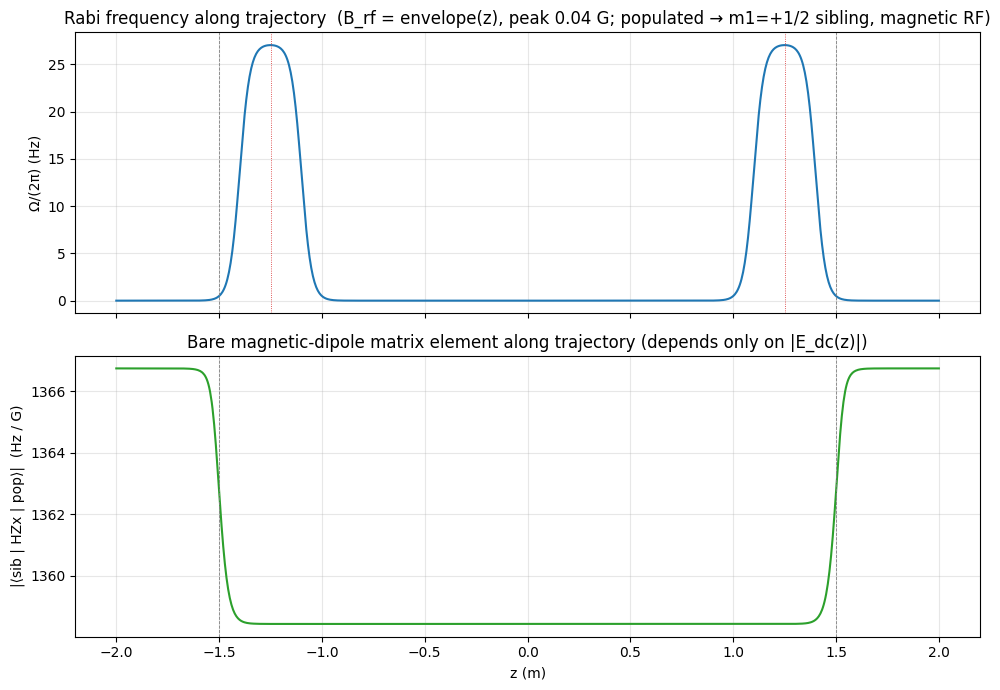

In [8]:
fig, (ax_rabi, ax_M) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax_rabi.plot(z_grid, rabi_z_Hz, color="C0", lw=1.5)
ax_rabi.axvline(-DC_HALF_WIDTH, ls="--", color="gray", lw=0.6)
ax_rabi.axvline(+DC_HALF_WIDTH, ls="--", color="gray", lw=0.6)
ax_rabi.axvline(Z_RF1, ls=":", color="C3", lw=0.6)
ax_rabi.axvline(Z_RF2, ls=":", color="C3", lw=0.6)
ax_rabi.set_ylabel("Ω/(2π) (Hz)")
ax_rabi.set_title(
    f"Rabi frequency along trajectory  (B_rf = envelope(z), peak {B_RF_AMPLITUDE} G; "
    f"populated → m1=+1/2 sibling, magnetic RF)"
)
ax_rabi.grid(alpha=0.3)

ax_M.plot(z_grid, abs_M_z, color="C2", lw=1.5)
ax_M.axvline(-DC_HALF_WIDTH, ls="--", color="gray", lw=0.6)
ax_M.axvline(+DC_HALF_WIDTH, ls="--", color="gray", lw=0.6)
ax_M.set_xlabel("z (m)")
ax_M.set_ylabel("|⟨sib | HZx | pop⟩|  (Hz / G)")
ax_M.set_title("Bare magnetic-dipole matrix element along trajectory (depends only on |E_dc(z)|)")
ax_M.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Plot B: vs |E_dc| (Stark-map view)

- **Top:** Rabi at peak amplitude — `Ω(|E|)/(2π) = (1/2) · B_RF_AMPLITUDE · |M(|E|)|`. Rabi frequency the molecule would see if it sat inside an RF coil at the given DC field.
- **Bottom:** Bare matrix element vs |E_dc|. For the direct nuclear-Zeeman case this should be only weakly dependent on the DC field (the Stark mixes J at fixed mJ, m1, m2; the nuclear Zeeman amplitude `⟨I_x⟩` between the two spin states is preserved).

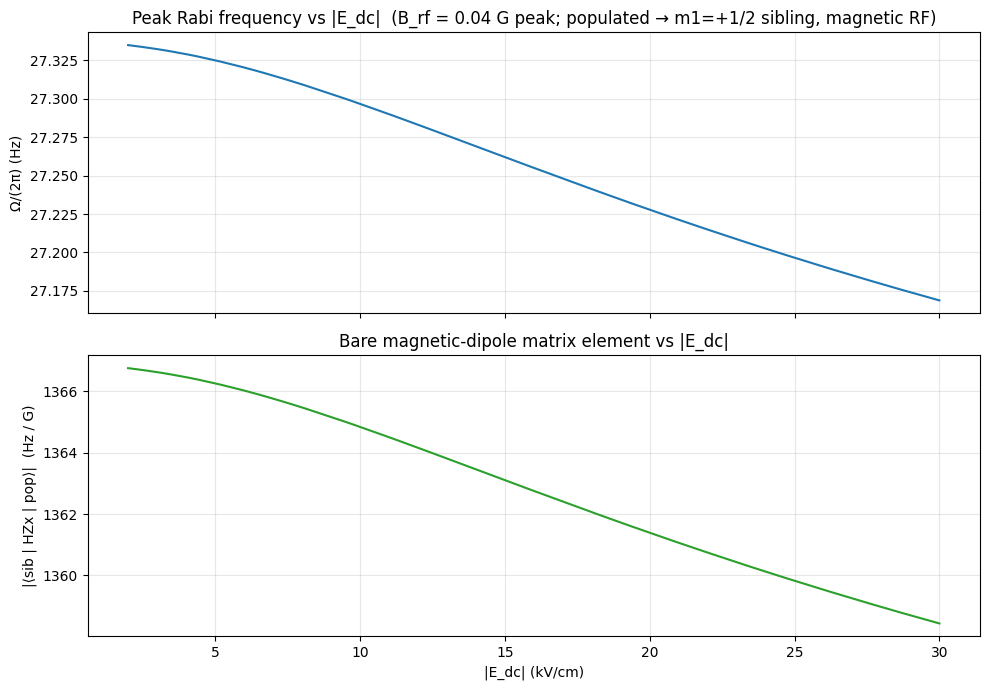

In [9]:
fig, (ax_rabi, ax_M) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax_rabi.plot(E_grid * 1e-3, rabi_E_Hz, color="C0", lw=1.5)
ax_rabi.set_ylabel("Ω/(2π) (Hz)")
ax_rabi.set_title(
    f"Peak Rabi frequency vs |E_dc|  (B_rf = {B_RF_AMPLITUDE} G peak; "
    f"populated → m1=+1/2 sibling, magnetic RF)"
)
ax_rabi.grid(alpha=0.3)

ax_M.plot(E_grid * 1e-3, abs_M_xE, color="C2", lw=1.5)
ax_M.set_xlabel("|E_dc| (kV/cm)")
ax_M.set_ylabel("|⟨sib | HZx | pop⟩|  (Hz / G)")
ax_M.set_title("Bare magnetic-dipole matrix element vs |E_dc|")
ax_M.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Notes

- **What's plotted:** the matrix element of the (bare) Zeeman magnetic-dipole operator `HZx` (Hz/G) between the Hungarian-tracked dressed eigenstates of the populated and m1=+1/2 sibling branches at each |E_dc|. RF amplitude (B_rf) enters only as a multiplicative factor in the Rabi panel.
- **RWA factor of 1/2.** `Ω/(2π) = (1/2) · B_rf · |⟨b|HZx|a⟩|`: the cosine RF has Fourier components at ±ω each with amplitude B_rf/2; only the resonant one contributes within RWA. Full π-pulse area is `Ω · t = π`, so `t_π = π / Ω`.
- **Selection rules.** `HZx` is the magnetic-dipole operator with B ∥ x̂. It includes the nuclear Zeeman terms `μ_Tl·I_Tl,x + μ_F·I_F,x`, which directly flip m1 or m2 by ±1 via `I±/2`. The bare matrix element `⟨sib_bare | HZx | pop_bare⟩ ≈ −1240 Hz/G` directly — no 2nd-order suppression. This is a textbook NMR-style nuclear-spin-flip transition.
- **Contrast with the (incorrect) electric picture.** `HSx` (electric dipole) is strictly diagonal in (m1, m2) — the molecular dipole acts only on rotational coordinates. The populated→sibling transition would be forbidden at 1st order and only appear via small spin-rotation admixtures, giving |M| ~ Hz/(V/cm). The correct magnetic picture gives |M| ~ kHz/G — direct and 1000× larger.
- **The 120 kHz match in the demo:** with `OMEGA_RF = 2π·120 kHz` and the populated↔sibling splitting of ~120 kHz throughout the trajectory (set by the Tl spin-rotation `c1·I_Tl·J` interaction), the magnetic RF is on-resonance the entire time the molecule is inside an RF coil.
- **B_RF_AMPLITUDE choice.** 0.04 G is a placeholder tuned so the pulse area in one coil ≈ π/2. The demo notebook hard-codes RF_AMPLITUDE = 20 V/cm (incorrectly labeled as electric); replace with the actual measured B_rf to get quantitative Rabi values.
- mJ, m1, m2 are conserved by the static DC Stark Hamiltonian (E ∥ ẑ, no nuclear-Stark coupling). The Hungarian-tracked branches preserve these labels even at high field; only J is mixed.
- Increase `JMAX` or `N_E` to verify convergence.